In [1]:
# DO NOT CONTAINERISE
# =====
# Dependency
# -----
# ! pip install -r requirements.txt
# ! pip list
# ! conda list

# ds.argo.to_zarr()
# -----
# ! pip install numcodecs
# ! pip install zarr

import os
import sys
import time
from datetime import datetime

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

import argopy
from argopy import DataFetcher
from SPARQLWrapper import SPARQLWrapper, JSON

# base settings
# -----
conf_vlab_name     = "ECVs"
# conf_workflow_name = "Argo"

# conf_workflow_id = f"wid-{datetime.now().strftime('%Y%m%d_%H%M%S%f')}"
param_workflow_name = "workflow name"

# dev
# -----
# library: --volume="//c/DockerShare/ECVs:/home/jovyan" naavre-fl-ecvs-jupyter:local
# NaaVRE: /home/jovyan/Virtual Labs/ECVs/Git public
# dir_code = os.path.join("/", "home", "jovyan", "Virtual Labs")
# if not os.path.exists(dir_code):
#     os.makedirs(dir_code)

# dir_data = os.path.join("/", "home", "jovyan", "Cloud Storage", "naa-vre-user-data")
# if not os.path.exists(dir_data):
#     os.makedirs(dir_data)

# conf_dir_code  = os.path.join(dir_code, "ECVs", "Git public", "library")
# conf_dir_data  = os.path.join(dir_data, "ECVs", conf_workflow_id)
# conf_dir_param = os.path.join(dir_data, "ECVs", conf_workflow_id)

# local
# -----
conf_dir_workspace = os.path.join("/", "home", "jovyan", "Cloud Storage")

conf_dir_data_local_tmp = os.path.join("/", "tmp", "data")

# MINIO
# -----
conf_minio_public_bucket      = "naa-vre-public"
conf_minio_public_bucket_root = f"vl-{conf_vlab_name.lower()}"
conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

conf_minio_user_bucket        = "naa-vre-user-data"
# conf_minio_user_bucket_root   = param_user_email
conf_minio_user_bucket_root   = conf_vlab_name
conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# API key
# -----
# If running under NaaVRE, input `your api key` with the correct value and input in the GUI:
# secret_SERVICE_KEY = "d18e08911c964d45912eb1e954adf994"
# secret_SERVICE_KEY = SecretsProvider().set_secret("secret_SERVICE_KEY")
# secret_SERVICE_KEY = SecretsProvider().get_secret("secret_SERVICE_KEY")

# Input param
# -----
# Argo surface region
# argopy.set_options(src=param_argo_src, ds='phy', mode='standard')
param_argo_src  ='erddap'     # "erddap" or "gdac"
param_argo_ds   = "phy"       # "phy" or "bgc"
param_argo_mode = "standard"  #

param_lon_min =  7
param_lon_max = 15
param_lat_min = 42
param_lat_max = 45
param_depth_min =  0
param_depth_max = 2000

param_start_date = '2022-05-01'
param_end_date   = '2022-08-01'


# Argo combine datasets
# argopy.set_options(src=param_argo_src, ds='bgc', mode='standard')
# param_src_bgc  ='erddap'  # 'erddap' or 'gdac'
# param_ds_bgc   = "bgc"
# param_mode_bgc = "standard"

# param_lon_west_bgc  =  0
# param_lon_east_bgc  = 20
# param_lat_south_bgc = 30
# param_lat_north_bgc = 50
# param_depth_min_bgc =  0
# param_depth_max_bgc = 2000
# param_date_min_bgc  = '2022-05-01'
# param_date_max_bgc  = '2022-08-01'

# Argo internal parameter names, iadopt
# param_src_iadopt  ='erddap'  # 'erddap' or 'gdac'
# param_mode_iadopt = "standard"

# param_lon_west_iadopt  =  0
# param_lon_east_iadopt  = 20
# param_lat_south_iadopt = 30
# param_lat_north_iadopt = 50
# param_depth_min_iadopt =  0
# param_depth_max_iadopt = 2000
# param_date_min_iadopt  = '2022-05-01'
# param_date_max_iadopt  = '2022-08-01'

# https://vocab.nerc.ac.uk/collection/EXV/current/
param_exv_list_iadopt = ["EXV018","EXV020","EXV028","EXV033","EXV029"]
# param_exv_list_iadopt = ["EXV018","EXV020","EXV028","EXV033","EXV029","EXV030"]
# param_exv_list_iadopt = ["EXV018","EXV020","EXV028","EXV033","EXV029","EXV030", "EXV018"]
# param_exv_list_iadopt = ["EXV017","EXV018","EXV019","EXV020","EXV028","EXV033", "EXV029", "EXV030"]

print("Finish: NaaVRE parameters")
print(f"Workspace public:")
print(f"  Root: {conf_minio_public_local_root}")
print(f"  Code: {conf_minio_public_local_code}")
print(f"  Data: {conf_minio_public_local_data}")

print(f"Workspace user:")
print(f"  Root: {conf_minio_user_local_root}")
print(f"  Code: {conf_minio_user_local_code}")
print(f"  Data: {conf_minio_user_local_data}")
print(f"  Log:  {conf_minio_user_local_flog}")


Finish: NaaVRE parameters
Workspace public:
  Root: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs
  Code: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs/code
  Data: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs/data
Workspace user:
  Root: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs
  Code: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/library
  Data: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/workflow name
  Log:  /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/workflow name/log.md


In [2]:
# ECVs, workflow start
# ---
# NaaVRE:
#  cell:
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

# prepare folders
# .....
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# .....
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Start"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

# func
# -----

# start
# -----

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {conf_minio_user_local_data}\n")

print(f"Finish: {workflow_step}")


workflow name
Finish: ECVs-Start


workflow name
<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo data fetcher for a space/time region
🗺  Domain: [x=7.00/15.00; y=42.00/45.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
🏊 User mode: standard
🟡+🔵 Dataset: phy
🌥  Performances: cache=False, parallel=False
<xarray.Dataset> Size: 153kB
Dimensions:          (N_POINTS: 1274)
Coordinates:
    LATITUDE         (N_POINTS) float64 10kB 43.67 43.67 43.67 ... 43.74 43.74
    LONGITUDE        (N_POINTS) float64 10kB 14.22 14.22 14.22 ... 14.19 14.19
    TIME             (N_POINTS) datetime64[ns] 10kB 2022-05-02T06:13:20 ... 2...
  * N_POINTS         (N_POINTS) int64 10kB 0 1 2 3 4 ... 1270 1271 1272 1273
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 10kB 10 10 10 10 10 10 ... 28 28 28 28 28
    DATA_MODE        (N_POINTS) <U1 5kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 5kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int6

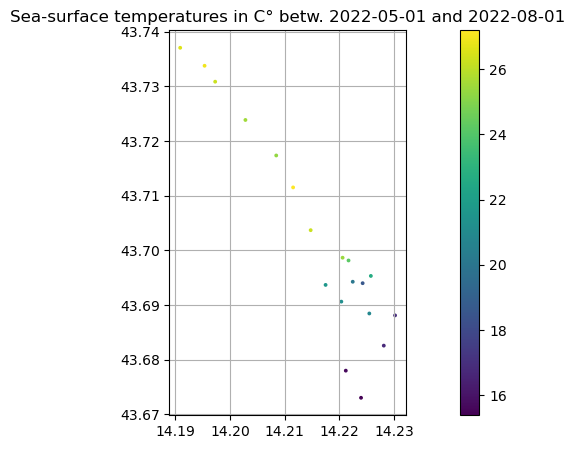

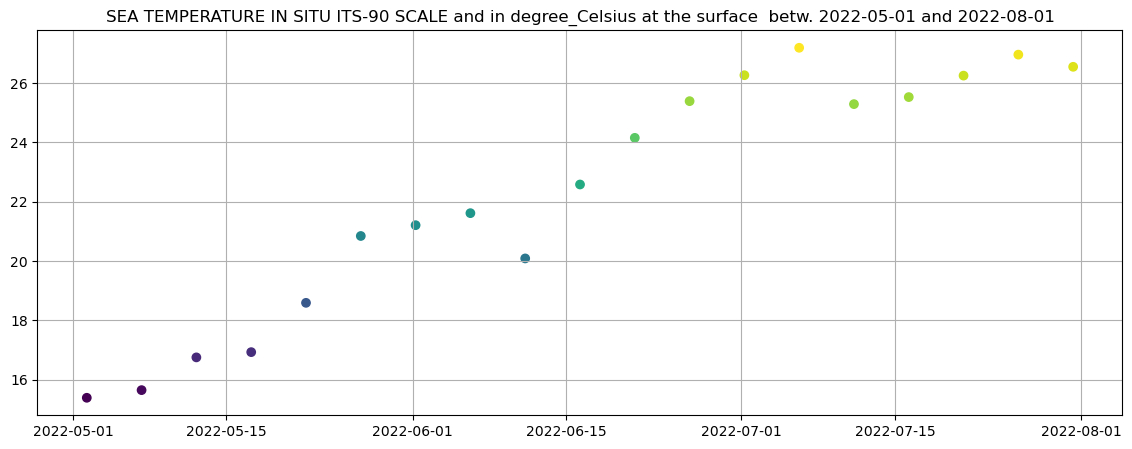

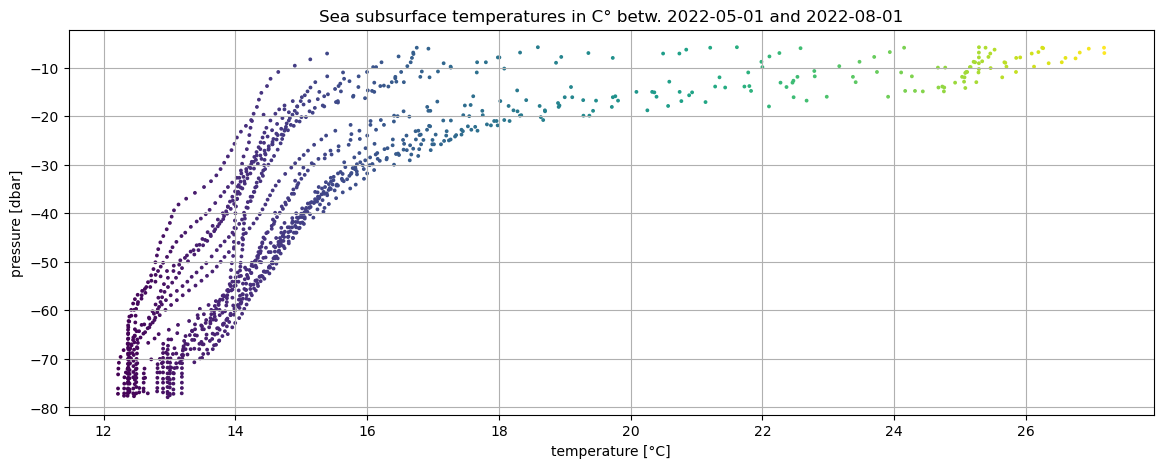

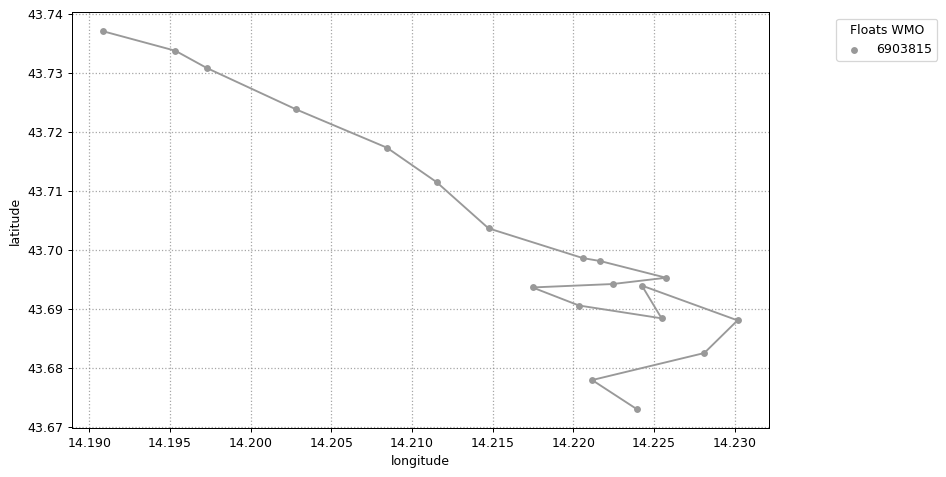

In [3]:
# ECVs, Argo surface region
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

# Surface temperature data around the Ligurian region
import os
import sys
import time
from datetime import datetime

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

import argopy
from argopy import DataFetcher
from SPARQLWrapper import SPARQLWrapper, JSON

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step   = f"{conf_vlab_name}-Argo surface region"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig_spatially = 'Sea-surface temperatures-spatially.jpg'
file_result_fig_spatially = os.path.join(conf_minio_user_local_data, fname_fig_spatially)

fname_fig_temporally = 'Sea-surface temperatures-temporally.jpg'
file_result_fig_temporally = os.path.join(conf_minio_user_local_data, fname_fig_temporally)

fname_fig_vertically = 'Sea-surface temperatures-vertically.jpg'
file_result_fig_vertically = os.path.join(conf_minio_user_local_data, fname_fig_vertically)

fname_fig_trajectory = 'Sea-surface temperatures-trajectories.jpg'
file_result_fig_trajectory = os.path.join(conf_minio_user_local_data, fname_fig_trajectory)

# func
# -----

# start
# -----
argopy.set_options(src=param_argo_src, ds=param_argo_ds, mode=param_argo_mode)

argopy_phy = DataFetcher().region([
    param_lon_min,    param_lon_max,
    param_lat_min,    param_lat_max,
    param_depth_min,  param_depth_max,
    param_start_date, param_end_date
])
print(argopy_phy)

ds = argopy_phy.to_xarray()
# ds = argopy_phy.to_dataframe()
# ds = argopy_phy.data
print(ds)

# Retrieve only surface points (closest to surface at each float ascent)
# .....
dsargo = ds.argo.point2profile()
dsargo_surf = dsargo.isel(N_LEVELS=0)

# Plot spatially
# .....
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Sea-surface temperatures in C° betw. ' + param_start_date + ' and ' + param_end_date)
plt.grid()
plt.scatter(
    dsargo_surf['LONGITUDE'],
    dsargo_surf['LATITUDE'],
    c=dsargo_surf['TEMP'],
    s=3,
    marker="o", cmap="viridis"
)
plt.colorbar()

plt.savefig(file_result_fig_spatially)
# plt.show()

# Plot temporally
# .....
plt.figure(figsize = (14, 5))
plt.title(ds['TEMP'].attrs['long_name'] + ' and in ' + ds['TEMP'].attrs['units'] + ' at the surface ' + ' betw. ' + param_start_date + ' and ' + param_end_date)
plt.scatter(
    dsargo_surf['TIME'],
    dsargo_surf['TEMP'],
    c=dsargo_surf['TEMP'],
    marker="o", cmap="viridis"
)
plt.grid()

plt.savefig(file_result_fig_temporally)
# plt.show()

# Plot Vertically
# .....
plt.figure(figsize = (14, 5))
plt.title('Sea subsurface temperatures in C° betw. ' + param_start_date + ' and ' + param_end_date)
plt.scatter(
    ds['TEMP'],
    -ds['PRES'],
    c=ds['TEMP'],
    s=3,
    marker="o", cmap="viridis"
)
plt.ylabel('pressure [dbar]') 
plt.xlabel('temperature [°C]')
plt.grid()

plt.savefig(file_result_fig_vertically)
# plt.show()

# Plot source floats trajectories
# .....
argopy_phy.plot('trajectory')
plt.savefig(file_result_fig_trajectory)

# zarr
# .....
# ds.argo.to_zarr(os.path.join(conf_dir_data, f"phy.zarr"))

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig_spatially}\n")
    fp_log.write(f"\nOutput: {file_result_fig_temporally}\n")
    fp_log.write(f"\nOutput: {file_result_fig_vertically}\n")
    fp_log.write(f"\nOutput: {file_result_fig_trajectory}\n")

print(f"Finish: {workflow_step}")


workflow name
<datafetcher.erddap>
⭐ Name: Ifremer erddap Argo data fetcher for a space/time region
🗺  Domain: [x=7.00/15.00; y=42.00/45.00; z=0.0/2000.0; t=2022-05-01/2022-08-01]
🔗 API: https://erddap.ifremer.fr/erddap
🏊 User mode: standard
🟡+🔵 Dataset: phy
🌥  Performances: cache=False, parallel=False
<xarray.Dataset> Size: 153kB
Dimensions:          (N_POINTS: 1274)
Coordinates:
    LATITUDE         (N_POINTS) float64 10kB 43.67 43.67 43.67 ... 43.74 43.74
    LONGITUDE        (N_POINTS) float64 10kB 14.22 14.22 14.22 ... 14.19 14.19
    TIME             (N_POINTS) datetime64[ns] 10kB 2022-05-02T06:13:20 ... 2...
  * N_POINTS         (N_POINTS) int64 10kB 0 1 2 3 4 ... 1270 1271 1272 1273
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 10kB 10 10 10 10 10 10 ... 28 28 28 28 28
    DATA_MODE        (N_POINTS) <U1 5kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 5kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int6

KeyError: "No variable named 'DOXY'. Variables on the dataset include [np.str_('CYCLE_NUMBER'), np.str_('DATA_MODE'), np.str_('DIRECTION'), np.str_('PLATFORM_NUMBER'), np.str_('POSITION_QC'), ..., 'N_PROF', 'N_LEVELS', np.str_('LATITUDE'), np.str_('LONGITUDE'), np.str_('TIME')]"

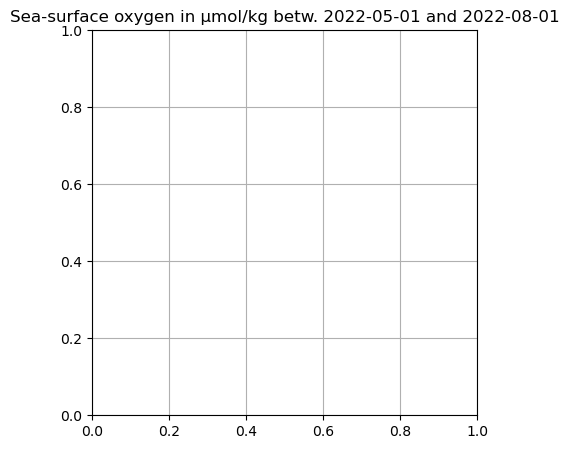

In [4]:
# ECVs, Argo combine datasets
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

# Combines oxygen and surface temperature data around the Ligurian region
# =====
# Here we are looking for argo data with both dissolved oxygen and temperature simultaneously measured.
# No data were accessible in the previously selected area.
# It has been slightly changed from the previous example.
import os
import sys
import time
from datetime import datetime

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

import argopy
from argopy import DataFetcher
from SPARQLWrapper import SPARQLWrapper, JSON

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step   = f"{conf_vlab_name}-Argo combine datasets"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig_spatially = 'Sea-surface oxygen-spatially.jpg'
file_result_fig_spatially = os.path.join(conf_minio_user_local_data, fname_fig_spatially)

fname_fig_temporally = 'Sea-surface oxygen-temporally.jpg'
file_result_fig_temporally = os.path.join(conf_minio_user_local_data, fname_fig_temporally)

fname_fig_vertically = 'Sea-surface oxygen-vertically.jpg'
file_result_fig_vertically = os.path.join(conf_minio_user_local_data, fname_fig_vertically)

# func
# -----

# start
# -----
argopy.set_options(src=param_argo_src, ds=param_argo_ds, mode=param_argo_mode)

argopy_bgc = DataFetcher(params="DOXY").region([
    param_lon_min,    param_lon_max,
    param_lat_min,    param_lat_max,
    param_depth_min,  param_depth_max,
    param_start_date, param_end_date
])
print(argopy_bgc)

ds = argopy_bgc.to_xarray()
#ds = argopy_bgc.to_dataframe()
#ds = argopy_bgc.data
print(ds)

# Retrieve only surface points (closest to surface at each float ascent)
# .....
dsargo = ds.argo.point2profile()
dsargo_surf = dsargo.isel(N_LEVELS=0)

# Plot spatially
# .....
plt.figure(figsize=(14,5))
plt.axes().set_aspect('equal')
plt.title('Sea-surface oxygen in µmol/kg betw. ' + param_start_date + ' and ' + param_end_date)
plt.grid()
plt.scatter(
    dsargo_surf['LONGITUDE'],
    dsargo_surf['LATITUDE'],
    c=dsargo_surf['DOXY'],
    marker="o", cmap="viridis"
)
plt.colorbar()

plt.savefig(file_result_fig_spatially)
# plt.show()

# Plot temporally
# .....
fig, ax1 = plt.subplots(figsize = (14, 5))
plt.title('Sea-surface temperatures in C° and dissolved oxygen in µmol/kg betw. ' + param_start_date + ' and ' + param_end_date)
ax2 = ax1.twinx()
ax1.scatter(dsargo_surf['TIME'], dsargo_surf['TEMP'], c='b', marker="o")
ax2.scatter(dsargo_surf['TIME'], dsargo_surf['DOXY'], c='r', marker="o")
ax1.set_xlabel('time')
ax1.set_ylabel('temperature',      color='b')
ax2.set_ylabel('dissolved oxygen', color='r')
plt.grid()

plt.savefig(file_result_fig_temporally)
# plt.show()

# Plot Vertically
# .....
fig, ax1 = plt.subplots(figsize = (14, 5))
plt.title('Sea subsurface temperatures in C° and dissolved oxygen in µmol/kg betw. ' + param_start_date + ' and ' + param_end_date)
ax2 = ax1.twiny()
ax1.scatter(ds['TEMP'], -ds['PRES'], c='b', s=3, marker="o")
ax2.scatter(ds['DOXY'], -ds['PRES'], c='r', s=3, marker="o")
ax1.set_ylabel('pressure [dbar]')
ax1.set_xlabel('temperature [°C]',           color='b')
ax2.set_xlabel('dissolved oxygen [µmol/kg]', color='r')
plt.grid()

plt.savefig(file_result_fig_vertically)
# plt.show()

# zarr
# -----
# ds.argo.to_zarr(os.path.join(conf_dir_data, f"bgc.zarr"))

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig_spatially}\n")
    fp_log.write(f"\nOutput: {file_result_fig_temporally}\n")
    fp_log.write(f"\nOutput: {file_result_fig_vertically}\n")

print(f"Finish: {workflow_step}")


In [ ]:
# ECVs, Argo internal parameter names, iadopt
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

# Surface temperature data around the Ligurian region
# =====
import os
import sys
import time
from datetime import datetime

import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

import argopy
from argopy import DataFetcher
from SPARQLWrapper import SPARQLWrapper, JSON

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step   = f"{conf_vlab_name}-Argo internal parameter names"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

# func
# -----

def iadopt(exv_code):
    # SPARQL endpoint
    endpoint_url = "https://vocab.nerc.ac.uk/sparql/"

    # Construct full identifier
    exv_identifier = f"SDN:EXV::{exv_code}"

    # Create the query with the user input
    query = f"""
    PREFIX owl:    <http://www.w3.org/2002/07/owl#>
    PREFIX dce:    <http://purl.org/dc/elements/1.1/>
    PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
    PREFIX iadopt: <https://w3id.org/iadopt/ont#> 
    PREFIX rdf:    <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
    
    SELECT DISTINCT ?r03 ?prefLabel ?notation
    
    WHERE {{
        ?exv a skos:Concept .
        ?exv dce:identifier "{exv_identifier}" .
      
        OPTIONAL {{?exv iadopt:hasApplicableMatrix ?matrix .}}
        ?exv iadopt:hasApplicableObjectOfInterest ?ooi .
        ?exv iadopt:hasApplicableProperty ?property .
        
        <http://vocab.nerc.ac.uk/collection/P01/current/> skos:member ?p01 .
        
        OPTIONAL {{ ?p01 iadopt:hasMatrix ?matrix . }}
        ?p01 iadopt:hasObjectOfInterest ?ooi .
        ?p01 iadopt:hasProperty ?property .
        
        <http://vocab.nerc.ac.uk/collection/R03/current/> skos:member ?r03 .
        
        ?r03 owl:sameAs ?p01
        
        OPTIONAL {{ ?r03 skos:prefLabel ?prefLabel . }}
        OPTIONAL {{ ?r03 skos:notation ?notation . }}
    
    }}
    """

    # Set up the SPARQL request
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)

    # Run the query and parse results
    results = sparql.query().convert()

    codes = []

    # Show results
    for result in results["results"]["bindings"]:
        uri = result.get("r03", {}).get("value", "")
        codes.append(uri.rstrip("/").split("/")[-1])

    return codes

# start
# -----
allds = {}

with open(conf_minio_user_local_flog, "a+") as fp_log:
    for exv in param_exv_list_iadopt:
        # Expected outputs:\n",
        # see rationale https://docs.google.com/document/d/1utc2zoJbGc6qwhrO1H5k7t8j-xj6Zq5Xr5lixD3LPsI/edit?tab=t.0 at Euro-Argo section\n",
        # EXV017 : ['TEMP'] - sea surface temperature\n",
        # EXV018 : ['TEMP'] - underneath sea level\n",
        # EXV019 : ['PSAL'] - sea surface salinity\n",
        # EXV020 : ['PSAL'] - underneath sea level\n",
        # EXV028 : ['DOXY', 'MLPL_DOXY']\n",
        # EXV033 : ['CHLA','BBP700','DOWN_IRRADIANCE380','DOWN_IRRADIANCE412','DOWN_IRRADIANCE490','DOWNWELLING_PAR'] # NVS is missing iop relationships\n",
        #                                                                                                              for BBP and irradiance\n",
        # EXV029 : ['MOLAR_NITRATE', 'NITRATE']\n",
        # EXV030 : ['PH_IN_SITU_TOTAL'] # https://vocab.nerc.ac.uk/collection/EXV/current/EXV030/?_profile=iop&_mediatype=text/html is missing \n",
        #                                hasApplicableProperty S06:S0600277\n",
        #                                hashasApplicableObjectOfInterest S21:S21S027\n"
        t_start=time.time()
    
        # STEP 1: get the Argo internal parameter names
        matching_r03s = iadopt(exv)
        
        str_print = f"## Extracting Argo data for {matching_r03s}"
        print(str_print)
        fp_log.write(f"{str_print}\n")
        
        # STEP 2: perform a match between possible parameters accepted by the argopy service (TO BE FINE-TUNED MORE PRECISELY)
        # The 'params' argument must have values in [BBP700,CDOM,CHLA,DOWNWELLING_PAR,DOWN_IRRADIANCE380,DOWN_IRRADIANCE412,
        # DOWN_IRRADIANCE490,DOXY,NITRATE,PRES,PSAL,TEMP]
        # accepted_params=[
        #     "BBP700",
        #     "CDOM",
        #     "CHLA",
        #     "DOWNWELLING_PAR", "DOWN_IRRADIANCE380", "DOWN_IRRADIANCE412", "DOWN_IRRADIANCE490",
        #     "DOXY",
        #     "NITRATE",
        #     "PRES",
        #     "PSAL",
        #     "TEMP"
        # ]
        accepted_params = np.concatenate((argopy.utils.list_bgc_s_variables(), argopy.utils.list_core_parameters()))
    
        matching_r03s = list(set(matching_r03s).intersection(set(accepted_params)))
        # matching_r03s = matching_r03s[0]

        str_print = f"Accepted by Argopy {matching_r03s}"
        print(str_print)
        fp_log.write(f"{str_print}\n")
        
        # STEP 3: look for which dataset (s) depending on requested parameters (TO BE FINE-TUNED MORE PRECISELY)
        if exv in ["EXV017", "EXV018", "EXV019", "EXV020"]:
            dstype='phy'
        else:
            if exv in ["EXV028", "EXV029", "EXV030", "EXV033"]:
                dstype='bgc'
            else:
                print ("ERROR: this EXV is not supported by Argo data")
        
        # STEP 4: call the service
        argopy.set_options(src=param_argo_src, ds=dstype, mode=param_argo_mode)
        argopy_tmp = DataFetcher(params=matching_r03s).region([
            param_lon_min,    param_lon_max,
            param_lat_min,    param_lat_max,
            param_depth_min,  param_depth_max,
            param_start_date, param_end_date
        ])
        
        str_print = f"\n```\n{argopy_tmp}\n```"
        print(str_print)
        fp_log.write(f"{str_print}\n")
        
        # STEP 5: prepare the output
        ds=argopy_tmp.to_xarray()
    
        # -----
        # ds.argo.to_zarr(os.path.join(conf_dir_data, f"{dstype}.zarr"))
    
        allds[exv] = ds
    
        str_print = f"\n```\n{ds}\n```"
        print(str_print)
        fp_log.write(f"{str_print}\n")
    
        t_end=time.time()
        str_print = "\nExecution_time = **{:.1f} s**".format(t_end - t_start)
        print(str_print)
        fp_log.write(f"{str_print}\n")

    # ds = argopy_tmp.to_dataframe()
    # ds = argopy_tmp.data
    # print(ds)
    
    # print("\n=====")
    # print(allds)

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")

print(f"Finish: {workflow_step}")


In [ ]:
# ECVs, workflow finish
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
# ...

import os
import sys
from datetime import datetime

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Finish"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

# func
# -----

# start
# -----

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {conf_minio_user_local_data}\n")

print(f"Finish: {workflow_step}")
